Data loaded successfully.

Original number of rows: 6325
Number of rows after filtering: 1410

Checking for missing values...
0

Checking for infinite values...
0

Class distribution before oversampling:
Consolidation         914
EndOfConsolidation     73
Name: Label, dtype: int64

Class distribution after SMOTE oversampling:
Consolidation         914
EndOfConsolidation    914
Name: Label, dtype: int64

Starting Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best hyperparameters found: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

--- Final Classification Report (on original test set) ---
                    precision    recall  f1-score   support

     Consolidation       0.94      0.90      0.92       392
EndOfConsolidation       0.15      0.23      0.18        31

          accuracy                           0.85       423
         macro avg       0.54      0.56      0.55       423
  

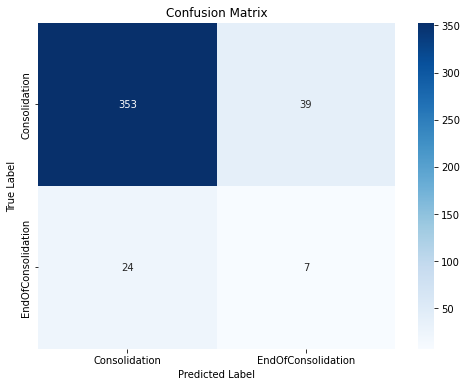


--- Feature Importances ---
                    feature  importance
14        Bollinger_Z_Score    0.082861
18            Stochastic_%D    0.074867
5             EMA5_Diff_Pct    0.074443
17            Stochastic_%K    0.070014
15                   ROC_10    0.057426
19            VWAP_Diff_Pct    0.051965
8              Volume_SMA10    0.051687
0     Total Traded Quantity    0.049909
11           Normalized_OBV    0.048307
9           Relative_Volume    0.046453
3           Normalized_High    0.043395
16                      RSI    0.042812
13                      ATR    0.042149
4            Normalized_Low    0.039848
7            EMA23_Diff_Pct    0.038669
2           Normalized_Open    0.038477
1             Weekly_Return    0.037877
12  Normalized_Weekly_Range    0.037836
10   Volume_Spike_Ratio_5Wk    0.035863
6            EMA13_Diff_Pct    0.035142


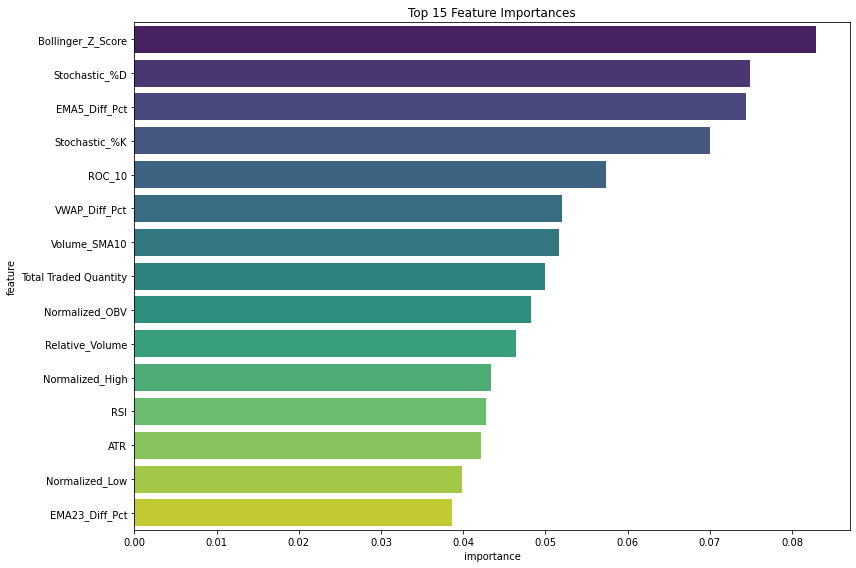


Analysis complete. The best model has been found and its performance and feature importances have been printed above.


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from imblearn.over_sampling import SMOTE

# --- 1. Load the data ---
# Load the data without setting an index column.
try:
    df = pd.read_csv("TreatedData.csv")
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Error: 'TreatedData.csv' not found. Please make sure the file is in the correct directory.")
    exit()

# --- 2. Data Cleaning ---
# Remove rows where the 'Label' column is 'NotImportant' or 'Breakout'.
df_filtered = df[~df['Label'].isin(['NotImportant', 'Breakout'])].copy()

print(f"\nOriginal number of rows: {len(df)}")
print(f"Number of rows after filtering: {len(df_filtered)}")

# Remove the 'Date' and 'Symbol' columns. The `Label` column will be our target variable.
columns_to_drop = ['Date', 'Symbol', 'Label']
if 'Unnamed: 0' in df_filtered.columns:
    columns_to_drop.append('Unnamed: 0')

try:
    features = df_filtered.drop(columns=columns_to_drop)
    target = df_filtered['Label']
except KeyError as e:
    print(f"Error dropping columns: {e}")
    print("Available columns:", df_filtered.columns.tolist())
    exit()

# --- 3. Handle Missing and Infinite Values ---
print("\nChecking for missing values...")
print(features.isnull().sum().sum()) # Print total sum
print("\nChecking for infinite values...")
print(np.isinf(features).sum().sum()) # Print total sum

features.fillna(features.mean(), inplace=True)
features.replace([np.inf, -np.inf], np.nan, inplace=True)
features.fillna(features.mean(), inplace=True)

# --- 4. Prepare data for the model ---
# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42, stratify=target)

# --- 5. Treat Class Imbalance with SMOTE ---
smote = SMOTE(random_state=42)
print("\nClass distribution before oversampling:")
print(y_train.value_counts())

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTE oversampling:")
print(y_train_resampled.value_counts())

# --- 6. Hyperparameter Tuning using GridSearchCV ---
# Define the parameter grid to search.
# We'll test different numbers of trees and max depths.
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Create a RandomForestClassifier instance.
model = RandomForestClassifier(random_state=42)

# Set up GridSearchCV. It will search for the best combination of parameters.
# 'f1_weighted' is a good metric for imbalanced classes.
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=2)

print("\nStarting Hyperparameter Tuning with GridSearchCV...")
grid_search.fit(X_train_resampled, y_train_resampled)

# Get the best model from the grid search.
best_model = grid_search.best_estimator_
print(f"\nBest hyperparameters found: {grid_search.best_params_}")

# --- 7. Model Evaluation ---
# Make predictions on the original, untouched test set using the best model.
y_pred = best_model.predict(X_test)

# Print a classification report.
print("\n--- Final Classification Report (on original test set) ---")
print(classification_report(y_test, y_pred))

# Generate and visualize a confusion matrix.
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# --- 8. Feature Importance Analysis ---
print("\n--- Feature Importances ---")
feature_importances = best_model.feature_importances_
feature_names = features.columns

# Create a DataFrame for better visualization and sorting.
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)
print(importance_df)

# Visualize feature importances.
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

print("\nAnalysis complete. The best model has been found and its performance and feature importances have been printed above.")


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, make_scorer, recall_score

def run_grid_search():
    """
    This script performs a Grid Search to find the optimal hyperparameters
    for the XGBoost model, with the scoring specifically set to maximize
    the recall for the 'EndOfConsolidation' class. It also corrects the
    ValueError by ensuring all labels are numerical before training.
    """
    try:
        # Load the preprocessed data from the CSV file
        df = pd.read_csv('TreatedData.csv', index_col=0)

        # Drop the 'Date' and 'Symbol' columns
        df.drop(columns=['Symbol'], inplace=True)
        
        # Filter the DataFrame to keep only the 'Consolidation' and 'EndOfConsolidation' labels.
        df_filtered = df[df['Label'].isin(['Consolidation', 'EndOfConsolidation'])].copy()

        if df_filtered.empty:
            print("Error: No 'Consolidation' or 'EndOfConsolidation' data found in the file.")
            return

        # Define the target variable (y) and features (X) from the filtered data
        X = df_filtered.drop('Label', axis=1)
        y = df_filtered['Label']

        # Use the top 15 features from our previous analysis
        top_15_features = [
            'Bollinger_Z_Score',
            'Stochastic_%D',
            'EMA5_Diff_Pct',
            'Stochastic_%K',
            'ROC_10',
            'VWAP_Diff_Pct',
            'Volume_SMA10',
            'Total Traded Quantity',
            'Normalized_OBV',
            'Relative_Volume',
            'Normalized_High',
            'RSI',
            'ATR',
            'Normalized_Low',
            'EMA23_Diff_Pct'
        ]

        # Filter the feature DataFrame to only include the selected top features
        X_selected = X[top_15_features]

        # Split the data into training and testing sets (80% train, 20% test)
        X_train, X_test, y_train, y_test = train_test_split(
            X_selected, y, test_size=0.2, random_state=42, stratify=y
        )
        
        # --- IMPORTANT CORRECTION HERE ---
        # Map labels to integers for XGBoost BEFORE applying SMOTE and GridSearchCV
        label_mapping = {'Consolidation': 0, 'EndOfConsolidation': 1}
        y_train_mapped = y_train.map(label_mapping)
        y_test_mapped = y_test.map(label_mapping)
        
        # Apply SMOTE to the training data to balance the classes
        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_mapped)
        
        # Define the hyperparameters to search through
        # We are now testing a more granular range for scale_pos_weight
        param_grid = {
            'n_estimators': [100, 200],
            'max_depth': [3, 5],
            'scale_pos_weight': [20, 30, 40, 50, 60, 70, 80, 90]
        }

        # Initialize the XGBClassifier
        xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
        
        # Define a custom scoring metric to prioritize recall on the positive class
        # Note: We now specify pos_label=1 because the labels are numerical
        recall_scorer = make_scorer(recall_score, pos_label=1)
        
        # Initialize GridSearchCV with the new scorer
        grid_search = GridSearchCV(
            estimator=xgb,
            param_grid=param_grid,
            scoring=recall_scorer,
            refit=True, # Refit the best model on the entire training set
            cv=3,       # 3-fold cross-validation
            verbose=2,  # Provides more detailed output
            n_jobs=-1   # Use all available cores
        )
        
        # Fit the grid search to the numerical training data
        print("Starting Grid Search with Recall Optimization...")
        grid_search.fit(X_train_smote, y_train_smote)
        print("Grid Search complete.")

        # Print the best parameters and the best score
        print("\n--- Best Parameters Found ---")
        print(grid_search.best_params_)
        print(f"Best cross-validation recall score: {grid_search.best_score_:.4f}")

        # Get the best model and evaluate it on the test set
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test)
        
        # The classification report uses the numerical predictions and original test labels
        print("\n--- Final Classification Report (Best XGBoost Model with Recall Optimization) ---")
        print(classification_report(y_test_mapped, y_pred, target_names=['Consolidation', 'EndOfConsolidation']))

    except FileNotFoundError:
        print("Error: TreatedData.csv not found. Please ensure the file is in the same directory.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Call the main function to run the model
if __name__ == "__main__":
    run_grid_search()


Starting Grid Search with Recall Optimization...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Grid Search complete.

--- Best Parameters Found ---
{'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 80}
Best cross-validation recall score: 0.9895

--- Final Classification Report (Best XGBoost Model with Recall Optimization) ---
                    precision    recall  f1-score   support

     Consolidation       0.95      0.71      0.81       261
EndOfConsolidation       0.13      0.52      0.20        21

          accuracy                           0.70       282
         macro avg       0.54      0.62      0.51       282
      weighted avg       0.89      0.70      0.77       282



In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.feature_selection import RFE
import numpy as np

def run_xgboost_grid_search():
    """
    This script performs a grid search to find the optimal 'scale_pos_weight'
    for the XGBoost model to find the best balance between precision and recall.
    It still uses SMOTEENN and RFE to handle the imbalanced data.
    """
    try:
        # Load the preprocessed data from the CSV file
        df = pd.read_csv('TreatedData.csv', index_col=0)

        # Drop the 'Date' and 'Symbol' columns
        df.drop(columns=['Symbol'], inplace=True)
        
        # Filter the DataFrame to keep only the 'Consolidation' and 'EndOfConsolidation' labels.
        df_filtered = df[df['Label'].isin(['Consolidation', 'EndOfConsolidation'])].copy()

        if df_filtered.empty:
            print("Error: No 'Consolidation' or 'EndOfConsolidation' data found in the file.")
            return

        # Define the target variable (y) and features (X) from the filtered data
        X = df_filtered.drop('Label', axis=1)
        y = df_filtered['Label']

        # Split the data into training and testing sets (80% train, 20% test)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        
        # Map labels to integers for XGBoost BEFORE applying SMOTEENN and RFE
        label_mapping = {'Consolidation': 0, 'EndOfConsolidation': 1}
        y_train_mapped = y_train.map(label_mapping)
        y_test_mapped = y_test.map(label_mapping)
        
        # Apply SMOTEENN to the training data to balance and clean the classes
        smoteenn = SMOTEENN(random_state=42)
        X_train_resampled, y_train_resampled = smoteenn.fit_resample(X_train, y_train_mapped)
        
        # Initialize the XGBoost model for RFE
        estimator = XGBClassifier(
            objective='binary:logistic', 
            eval_metric='logloss',
            use_label_encoder=False, 
            n_estimators=100,
            max_depth=3,
            random_state=42
        )

        # Initialize Recursive Feature Elimination (RFE)
        rfe = RFE(estimator=estimator, n_features_to_select=10, step=1)
        
        # Fit RFE on the resampled training data to find the best features
        print("Starting Recursive Feature Elimination...")
        rfe.fit(X_train_resampled, y_train_resampled)
        print("RFE complete.")

        # Get the selected features
        selected_features = X_train.columns[rfe.support_]
        print("\n--- Selected Features (RFE) ---")
        print(list(selected_features))

        # Filter the original datasets to use only the selected features
        X_train_rfe = X_train[selected_features]
        X_test_rfe = X_test[selected_features]
        
        # Re-apply SMOTEENN on the selected features
        X_train_rfe_resampled, y_train_rfe_resampled = smoteenn.fit_resample(X_train_rfe, y_train_mapped)
        
        # Define the parameter grid for GridSearchCV
        param_grid = {
            'scale_pos_weight': [1, 5, 10, 25, 50, 75, 100]
        }
        
        # Initialize the XGBoost model for grid search
        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            use_label_encoder=False,
            n_estimators=200, 
            max_depth=5,      
            random_state=42
        )
        
        # Initialize GridSearchCV
        # We will use 'f1_score' as the scoring metric because it balances precision and recall
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring='f1',
            cv=5,
            verbose=1
        )
        
        print("\nStarting Grid Search for optimal 'scale_pos_weight'...")
        grid_search.fit(X_train_rfe_resampled, y_train_rfe_resampled)
        print("Grid Search complete.")
        
        best_scale_pos_weight = grid_search.best_params_['scale_pos_weight']
        print(f"\n--- Optimal scale_pos_weight found: {best_scale_pos_weight} ---")

        # Train the final model with the best parameter
        final_model = grid_search.best_estimator_
        
        # Get the predictions on the test set
        y_pred = final_model.predict(X_test_rfe)
        
        # Print the final classification report
        print("\n--- Final Classification Report (XGBoost with Optimized Parameters) ---")
        print(classification_report(y_test_mapped, y_pred, target_names=['Consolidation', 'EndOfConsolidation']))

    except FileNotFoundError:
        print("Error: TreatedData.csv not found. Please ensure the file is in the same directory.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Call the main function to run the model
if __name__ == "__main__":
    run_xgboost_grid_search()


Starting Recursive Feature Elimination...
RFE complete.

--- Selected Features (RFE) ---
['Total Traded Quantity', 'Normalized_Open', 'Volume_SMA10', 'Relative_Volume', 'Volume_Spike_Ratio_5Wk', 'Bollinger_Z_Score', 'RSI', 'Stochastic_%K', 'Stochastic_%D', 'VWAP_Diff_Pct']

Starting Grid Search for optimal hyperparameters...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Grid Search complete.

--- Optimal Hyperparameters found: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'scale_pos_weight': 1} ---

--- Final Classification Report (XGBoost with Comprehensive Tuning) ---
                    precision    recall  f1-score   support

     Consolidation       0.95      0.81      0.87       261
EndOfConsolidation       0.15      0.43      0.23        21

          accuracy                           0.78       282
         macro avg       0.55      0.62      0.55       282
      weighted avg       0.89      0.78      0.82       282



In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import ADASYN
import lightgbm as lgb
from sklearn.metrics import classification_report, f1_score, precision_recall_curve
import numpy as np
import sys
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

def run_lgbm_ensemble_cost_sensitive():
    """
    This script implements ensemble methods and cost-sensitive learning
    to improve the model's performance on the minority class.
    It uses a StackingClassifier with LightGBM and RandomForest as base estimators,
    and includes a final step to find the optimal classification threshold.
    """
    try:
        # Load the preprocessed data from the CSV file
        df = pd.read_csv('TreatedData.csv')

        # Drop columns that are not suitable for features, including the unnamed index column
        # and the 'Date' and 'Symbol' columns.
        df.drop(columns=['Date', 'Symbol'], inplace=True)

        # Convert all feature columns to numeric, coercing errors to NaN.
        # We need to make sure the Label column is not converted
        for col in df.columns.drop('Label'):
            df[col] = pd.to_numeric(df[col], errors='coerce')

        # Drop rows with any NaN values that might have been created during conversion.
        df.dropna(inplace=True)

        # Filter the DataFrame to keep only the 'Consolidation' and 'EndOfConsolidation' labels.
        df_filtered = df[df['Label'].isin(['Consolidation', 'EndOfConsolidation'])].copy()

        if df_filtered.empty:
            print("Error: No 'Consolidation' or 'EndOfConsolidation' data found in the file after cleaning.")
            sys.exit()

        # Define the target variable (y) and features (X) from the filtered data
        X = df_filtered.drop('Label', axis=1)
        y = df_filtered['Label']

        # Map labels to integers for the LightGBM model
        label_mapping = {'Consolidation': 0, 'EndOfConsolidation': 1}
        y = y.map(label_mapping)

        # Split the data into training and testing sets (80% train, 20% test)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        
        # Apply ADASYN to the training data to balance the classes.
        print("Shape before ADASYN:", X_train.shape)
        print("Class distribution before ADASYN:", np.unique(y_train, return_counts=True))
        
        adasyn = ADASYN(random_state=42)
        X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)
        
        print("Shape after ADASYN:", X_train_resampled.shape)
        print("Class distribution after ADASYN:", np.unique(y_train_resampled, return_counts=True))

        # Define the base estimators for the StackingClassifier.
        # We use class_weight='balanced' for cost-sensitive learning,
        # which automatically adjusts weights to handle class imbalance.
        estimators = [
            ('lgbm', lgb.LGBMClassifier(objective='binary', random_state=42, class_weight='balanced')),
            ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
        ]

        # Define the meta-estimator (final classifier that takes the base predictions).
        # We can use a simple Logistic Regression or another classifier.
        final_estimator = lgb.LGBMClassifier(objective='binary', random_state=42, class_weight='balanced')

        # Define the StackingClassifier. This is our ensemble model.
        # It trains the base estimators and uses a final estimator to combine their predictions.
        stacking_classifier = StackingClassifier(
            estimators=estimators,
            final_estimator=final_estimator,
            cv=5, # Number of cross-validation folds for training the final estimator
            n_jobs=-1 # Use all available cores
        )

        # Define a simplified parameter grid for the StackingClassifier's final estimator.
        # We will tune some key parameters for the LightGBM final estimator.
        param_grid = {
            'final_estimator__num_leaves': [15, 31, 50],
            'final_estimator__learning_rate': [0.01, 0.05, 0.1],
        }
        
        # Initialize GridSearchCV with a focus on F1-score for the minority class
        grid_search = GridSearchCV(
            estimator=stacking_classifier,
            param_grid=param_grid,
            scoring='f1', # Use F1-score for balancing precision and recall
            cv=5,
            verbose=1,
            n_jobs=-1 # Use all available cores for faster processing
        )
        
        print("\nStarting Grid Search for optimal hyperparameters for the StackingClassifier...")
        grid_search.fit(X_train_resampled, y_train_resampled)
        print("Grid Search complete.")
        
        print("\n--- Best parameters found by Grid Search ---")
        print(grid_search.best_params_)

        # Train the final ensemble model with the best parameters
        final_model = grid_search.best_estimator_
        
        # Predict probabilities on the test set to find the optimal threshold
        y_scores = final_model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class (1)

        # Find the best threshold for the minority class
        precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
        
        # Replace NaN in f1_scores with 0 for cleaner processing
        f1_scores = np.nan_to_num(f1_scores)
        
        optimal_idx = np.argmax(f1_scores)
        optimal_threshold = thresholds[optimal_idx]
        
        print(f"\n--- Optimal classification threshold found: {optimal_threshold:.4f} ---")

        # Get the final predictions on the test set using the optimal threshold
        y_pred_optimal = (y_scores >= optimal_threshold).astype(int)
        
        # Print the final classification report
        print("\n--- Final Classification Report (StackingClassifier with Optimized Parameters & Threshold) ---")
        print(classification_report(y_test, y_pred_optimal, target_names=['Consolidation', 'EndOfConsolidation']))

    except FileNotFoundError:
        print("Error: 'TreatedData.csv' not found. Please ensure the file is in the same directory.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Call the main function to run the model
if __name__ == "__main__":
    run_lgbm_ensemble_cost_sensitive()


Shape before ADASYN: (1128, 20)
Class distribution before ADASYN: (array([0, 1]), array([1045,   83]))
Shape after ADASYN: (2096, 20)
Class distribution after ADASYN: (array([0, 1]), array([1045, 1051]))

Starting Grid Search for optimal hyperparameters for the StackingClassifier...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 840, number of negative: 836
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000795 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 1676, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 672, number of negative: 669
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000578 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 1341, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 672, number of negative: 669
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000519 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 1341, number of used features:

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 673, number of negative: 669
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000712 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 1342, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 673, number of negative: 669
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000486 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 1342, number of used features: 2

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 673, number of negative: 669
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000532 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 1342, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 841, number of negative: 836
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000405 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 1677, number of used features: 2

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 672, number of negative: 668
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 1340, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 672, number of negative: 669
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000469 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 1341, number of used features:

...

/var/folders/2m/3zds335164v45cqnqxfcnx9w0000gn/T/ipykernel_12464/1323538523.py:117: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precisions * recalls) / (precisions + recalls)


[LightGBM] [Info] Number of positive: 841, number of negative: 836
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 356
[LightGBM] [Info] Number of data points in the train set: 1677, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 841, number of negative: 836
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000273 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 356
[LightGBM] [Info] Number of data points in the train set: 1677, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No fu

[LightGBM] [Info] Number of positive: 841, number of negative: 836
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000359 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 356
[LightGBM] [Info] Number of data points in the train set: 1677, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 841, number of negative: 836
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000283 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 356
[LightGBM] [Info] Number of data points in the train set: 1677, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No fu

[LightGBM] [Info] Number of positive: 841, number of negative: 836
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000262 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 356
[LightGBM] [Info] Number of data points in the train set: 1677, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 841, number of negative: 836
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000251 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 356
[LightGBM] [Info] Number of data points in the train set: 1677, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No fu

[LightGBM] [Info] Number of positive: 841, number of negative: 836
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 356
[LightGBM] [Info] Number of data points in the train set: 1677, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 841, number of negative: 836
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000195 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 356
[LightGBM] [Info] Number of data points in the train set: 1677, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number o